# The Bohr Model – hydrogen-like atoms, effective Hamiltonian, and spectral series

## Step 0 – Imports and constants

**Theory**

We will use the SI units for dynamics (J, s, m) and eV for reporting energies. Use:

$$\hbar = \frac{h}{2\pi}, \,\ 1\text{eV} = e \text{J}.$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy import constants

# Use these exact standard constants
me = constants.m_e
mp = constants.m_p
R_inf = constants.Rydberg
   
h = 6.62607015e-34
hbar = h/(2*np.pi)
c = 299792458.0
eC = 1.602176634e-19
eps0 = 8.8541878128e-12
#me = 9.1093837015e-31
#mp = 1.6726219259552e-27
#R_inf = 1.0973731568e7

/home/jp/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Step 1 – Bohr energies $E_n$ (hydrogen-like atoms)

**Theory**

In the Bohr model, the bound tate energies are

$$E_n = -13.6\frac{Z^2}{n^2}\text{eV}, \,\ n=1,2,\dots$$

The negative sign indicates a bound electron. The **ionization energy** from the ground state is 13.6 eV for hydrogen ($Z=1$). 

We will use a truncated basis $\{|n\rangle\}_{n=1}^{n_{\max}}$.

In [3]:
n_max = 8
Z = 1

n = np.arange(1, n_max+1)

En_eV = -13.6*Z**2/n**2
En_J = En_eV * eC

print("E_1 (eV) =", En_eV[0])

E_1 (eV) = -13.6


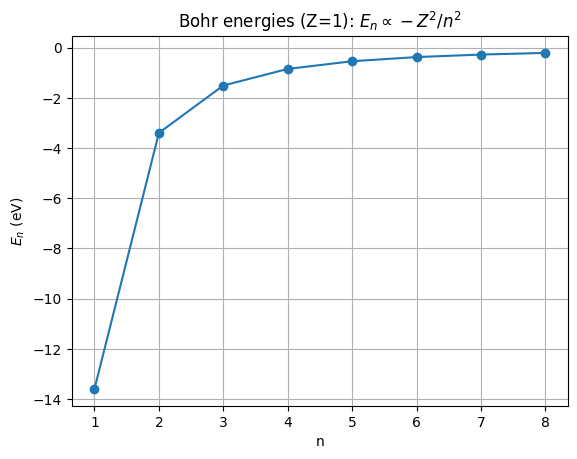

In [4]:
plt.figure()
plt.plot(n, En_eV, marker="o")
plt.xlabel("n")
plt.ylabel(r"$E_n$ (eV)")
plt.title(f"Bohr energies (Z={Z}): $E_n \propto -Z^2/n^2$")
plt.grid(True)
plt.show()

## Step 2 – Effective Hamiltonian $\hat{H}_{\text{eff}}$

**Theory**

In quantum mechanics, the Hamiltonian $\hat{H}$ is the **energy operator**. Stationary states satisfy

$$\hat{H}|\phi_k\rangle = E_k|\phi_k\rangle,$$

and time evolution is governed by

$$i\hbar = \frac{\partial}{\partial t}|\psi(t)\rangle.$$

To focus on spectroscopy, we build an **effective Hamiltonian** on the truncated basis $|n\rangle:$

$$\hat{H}_{\text{eff}}=\sum_{n=1}^{n_{\max}}E_n |n\rangle\langle n|.$$

In the $|n\rangle$ basis this is a **diagonal matrix** witn entries $E_n$.


In [5]:
H_energy = qt.Qobj(np.diag(En_J))
H_proj_energy = 0 * H_energy
for idx, E in enumerate(En_J):
  ket = qt.basis(n_max, idx)
  H_proj_energy += E * (ket * ket.dag())

print("||H_energy - H_proj_energy|| =", (H_energy - H_proj_energy).norm())

evals_J = H_energy.eigenenergies()
evals_eV = evals_J /eC
print("First 5 eigenenergies (eV):", np.round(evals_eV[:5], 6))

H = H_energy

||H_energy - H_proj_energy|| = 0.0
First 5 eigenenergies (eV): [-13.6       -3.4       -1.511111  -0.85      -0.544   ]


In [6]:
evals_J

array([-2.17896022e-18, -5.44740056e-19, -2.42106691e-19, -1.36185014e-19,
       -8.71584089e-20, -6.05266728e-20, -4.44685760e-20, -3.40462535e-20])

In [7]:
print("Check: E_n from fomrula (eV) =", np.round(En_eV[:5],6))
print("Check: E_n from diagonalization (eV) =", np.round((H_energy.eigenenergies()/eC)[:5],6))

Check: E_n from fomrula (eV) = [-13.6       -3.4       -1.511111  -0.85      -0.544   ]
Check: E_n from diagonalization (eV) = [-13.6       -3.4       -1.511111  -0.85      -0.544   ]


## Step 3 – Transitions and the Rydberg formula

**Theory**

A transition $n_i \rightarrow n_f$ emits/absorbs a photon with energy

$$h\nu = |E_{n_i}-E_{n_j}|.$$

In spectroscopy we often use the **wavenumber** $\bar{\nu}=1/\lambda$, and for hydrogen-like atoms:

$$\bar{\nu}=R_{\infty}Z^2\Big(\frac{1}{n_f^2}-\frac{1}{n_i^2}\Big), \,\ n_i>n_f.$$

**Notation:** $n_f =$ final (lower) level, $n_i=$ initial (upper) level.


In [8]:
def rydberg_wavelength(nf, ni, Z=1, R=R_inf):
    #nf = int(nf); ni = int(ni); Z = int(Z)
    if np.any(nf < 1) or np.any(ni < 1) or np.any(Z < 1):
        raise ValueError("nf, ni, and Z must be positive integers.")
    if np.any(ni <= nf):
        raise ValueError("Require ni > nf for a transition (ni -> nf).")
    inv_lambda = R * (Z**2) * (1.0/(nf**2)-1.0/(ni**2))
    return 1.0/inv_lambda

# Balmer (nf=2):ni=3..10
for ni in range(3,11):
    lam_nm = rydberg_wavelength(2, ni, Z=1, R=R_inf,)*1e9
    print(f"n={ni}->2:{lam_nm:3f}nm")


n=3->2:656.112276nm
n=4->2:486.009094nm
n=5->2:433.936691nm
n=6->2:410.070173nm
n=7->2:396.907426nm
n=8->2:388.807275nm
n=9->2:383.442239nm
n=10->2:379.694604nm


## Step 4 – Stick spectra for spectral series

**Theory**

Hydrogen series correspond to a fixed final level $n_f$:

  - Lyman: $n_f=1$ (UV)

  - Balmer: $n_f=2$ (visible/near-UV)

  - Paschen: $n_f=3$ (IR)

  - Brackett: $n_f = 4$ (IR)

  - Pfund: $n_f= 5$ (IR)

A stick spectrum places a vertical line at each predicted wavelength $\lambda_{n_i\rightarrow n_f}$. We will plot sticks without attempting a full intensity model. 


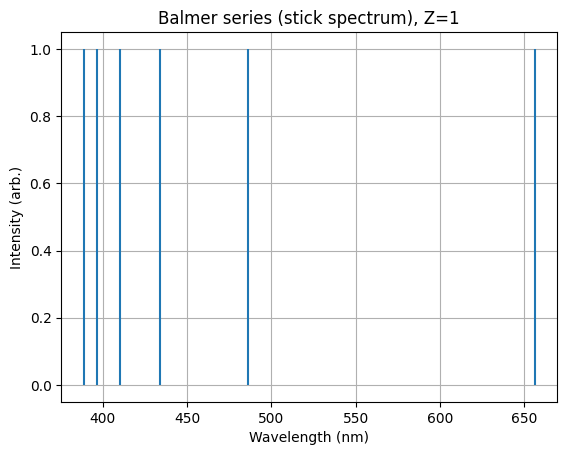

In [9]:
def stick_spectrum(nf, nmax, Z=1, R=R_inf):
    LAMBDA_NM = list()
    for ni in range((nf + 1),(nmax + 1)):
        lambda_m = rydberg_wavelength(nf, ni, Z, R)
        lambda_nm = lambda_m * 1e9
        LAMBDA_NM.append(lambda_nm)
    return(LAMBDA_NM)

lam_nm = stick_spectrum(2, n_max, Z=1, R=R_inf)
fig, ax = plt.subplots()         
ax.vlines(lam_nm, 0, 1)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Intensity (arb.)")
ax.set_title("Balmer series (stick spectrum), Z=1")
ax.grid(True)
plt.show()

## Step 5 – Hydrogenic ions: dependence on (Z)

**Theory**

Bohr energies scale as $E_n \propto -Z^2$. Transition energies increase with $Z^2$, so wavelengths tend to shift to **shorter** values as $Z$ increases.

We will compare the same series  for multiple $Z$ values.

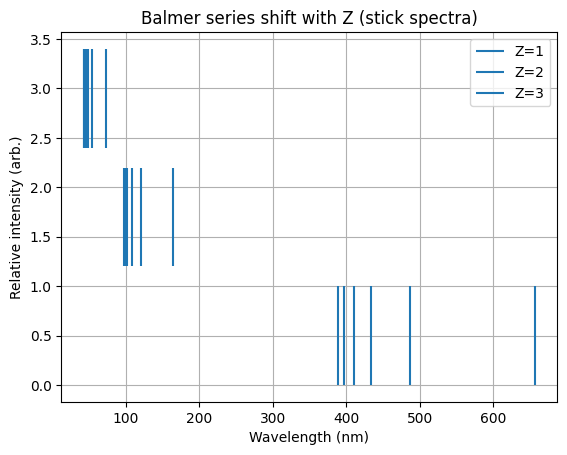

In [13]:
fig, ax = plt.subplots()
for i, Zval in enumerate([1, 2, 3]):
    lam_nm = stick_spectrum(2, n_max, Z=Zval, R=R_inf)
    y0 = 1.2 * i
    ax.vlines(lam_nm, y0, y0 + 1, label=f"Z={Zval}")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Relative intensity (arb.)")
ax.set_title("Balmer series shift with Z (stick spectra)")
ax.legend()
ax.grid(True)
plt.show()

## Step 6 – Finite nuclear mass: reduced-mass correction

**Theory**

$R_{\infty}$ corresponds to the infinite nuclear-mass approximation. A basic correction replaces $m_e$ by the reduced mass $\mu$:

$$\mu=\frac{m_eM}{m_e+M}, \,\ R\approx R_{\infty}\Big(\frac{\mu}{m_e}\Big).$$

For hydrogen, $M\approx m_p$. This produces small wavelength shifts that you will quantify.

In [14]:
M = mp
mu = (me*M)/(me+M)
R_corr = R_inf * (mu/me)

print("mu/me =", mu/me)
print("R_corr (1/m) =", R_corr)

mu/me = 0.9994556794247602
R_corr (1/m) = 10967758.340277294


n=3 -> 2: lambda_inf=656.112276 nm, lambda_corr=656.469606 nm, delta_lambda=357.330 pm
n=4 -> 2: lambda_inf=486.009094 nm, lambda_corr=486.273782 nm, delta_lambda=264.689 pm
n=5 -> 2: lambda_inf=433.936691 nm, lambda_corr=434.173020 nm, delta_lambda=236.329 pm
n=6 -> 2: lambda_inf=410.070173 nm, lambda_corr=410.293504 nm, delta_lambda=223.331 pm
n=7 -> 2: lambda_inf=396.907426 nm, lambda_corr=397.123589 nm, delta_lambda=216.163 pm
n=8 -> 2: lambda_inf=388.807275 nm, lambda_corr=389.019026 nm, delta_lambda=211.751 pm


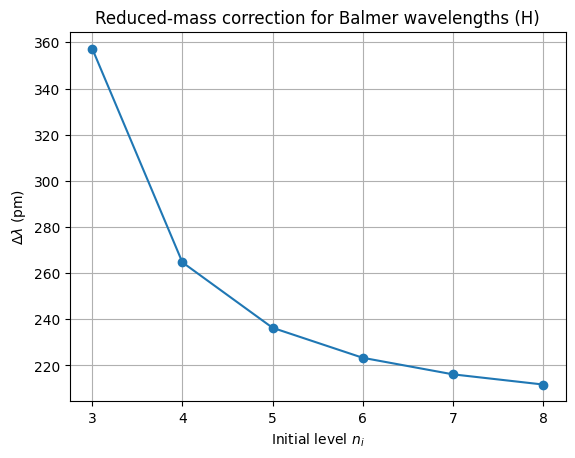

In [15]:
ni_vals = np.arange(3, n_max + 1)

lam_inf = rydberg_wavelength(2, ni_vals, Z, R_inf)
lam_corr = rydberg_wavelength(2, ni_vals, Z, R_corr)
    
delta_pm = (lam_corr - lam_inf) * 1e12

for ni, L0, Lc, d in zip(ni_vals, lam_inf*1e9, lam_corr*1e9, delta_pm):
    print(f"n={ni} -> 2: lambda_inf={L0:.6f} nm, lambda_corr={Lc:.6f} nm, delta_lambda={d:.3f} pm")

plt.figure()
plt.plot(ni_vals, delta_pm, marker="o")
plt.xlabel(r"Initial level $n_i$")
plt.ylabel(r"$\Delta\lambda$ (pm)")    
plt.title("Reduced-mass correction for Balmer wavelengths (H)")
plt.grid(True)
plt.show()

## Step 7 – Toy relaxation models (open quantum system)

**Theory**

To visualize relaxation from an excited level to the ground state, we use an effective Lindblad master equation:

$$\frac{d \rho}{d t} = -\frac{i}{\hbar}[\hat{H},\rho]+\sum_k\Big(\hat{c}_k\rho\hat{c}_k^\dagger -\frac{1}{2}\{\hat{c}_k^\dagger\hat{c}_k,\rho\}\Big).$$

We choose collapse operators for adjacent decays:

$$\hat{c}_n = \sqrt{\gamma_n}|n-1\rangle\langle n|, \,\ n=2,\dots,n_{\max}.$$

A simple rate model is $\gamma_n=\gamma_0/n^3$ (you may choose $\gamma_0$). This is an **effective** model (not a full QED derivation).

In [20]:
tlist

array([0.00000000e+00, 5.01253133e-10, 1.00250627e-09, 1.50375940e-09,
       2.00501253e-09, 2.50626566e-09, 3.00751880e-09, 3.50877193e-09,
       4.01002506e-09, 4.51127820e-09, 5.01253133e-09, 5.51378446e-09,
       6.01503759e-09, 6.51629073e-09, 7.01754386e-09, 7.51879699e-09,
       8.02005013e-09, 8.52130326e-09, 9.02255639e-09, 9.52380952e-09,
       1.00250627e-08, 1.05263158e-08, 1.10275689e-08, 1.15288221e-08,
       1.20300752e-08, 1.25313283e-08, 1.30325815e-08, 1.35338346e-08,
       1.40350877e-08, 1.45363409e-08, 1.50375940e-08, 1.55388471e-08,
       1.60401003e-08, 1.65413534e-08, 1.70426065e-08, 1.75438596e-08,
       1.80451128e-08, 1.85463659e-08, 1.90476190e-08, 1.95488722e-08,
       2.00501253e-08, 2.05513784e-08, 2.10526316e-08, 2.15538847e-08,
       2.20551378e-08, 2.25563910e-08, 2.30576441e-08, 2.35588972e-08,
       2.40601504e-08, 2.45614035e-08, 2.50626566e-08, 2.55639098e-08,
       2.60651629e-08, 2.65664160e-08, 2.70676692e-08, 2.75689223e-08,
      

In [19]:
result = qt.mesolve(H, rho0, tlist, c_ops, e_ops=[])
result.states[0]

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]

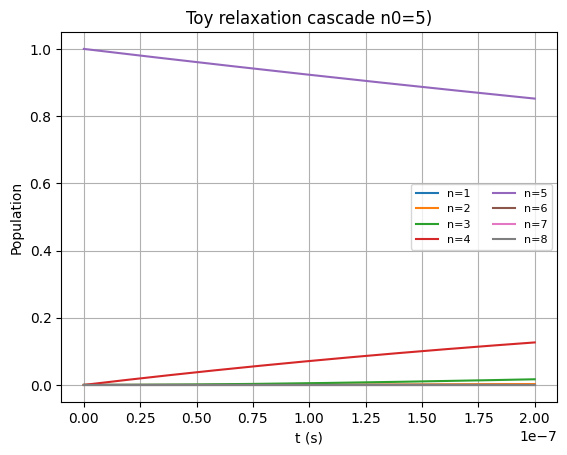

In [21]:
n0 = 5
rho0 = qt.ket2dm(qt.basis(n_max, n0 - 1))

gamma0 = 1.0e8
c_ops = []
for n_level in range(2, n_max + 1):
    gamma_n = gamma0 / (n_level**3)
    ket_down = qt.basis(n_max, n_level - 2)
    bra_up = qt.basis(n_max, n_level - 1).dag()
    c_ops.append(np.sqrt(gamma_n) * (ket_down * bra_up))

t_max = 2.0e-7
tlist = np.linspace(0, t_max, 400)

result = qt.mesolve(H, rho0, tlist, c_ops, e_ops=[])

proj_ops = [qt.basis(n_max, k) * qt.basis(n_max, k).dag() for k in range(n_max)]
pops = qt.expect(proj_ops, result.states)

plt.figure()
for k in range(n_max):
    plt.plot(tlist, pops[k], label=f"n={k+1}")
plt.xlabel("t (s)")
plt.ylabel("Population")
plt.title(f"Toy relaxation cascade n0={n0})")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.show()    

## Step 8 – Interpretation: cascade photons vs full spectral series

**Theory**

I the toy model only allows adjacent decays $n\rightarrow n-1$, then emitted photons correspond only to those steps. However, the full hydrogen spectrum contains transitions with many possible $\Delta n$ (subject to selection rules in a more complete model).

Here you will compare (qualitatively) the set of wavelengths from the cascade with the Rydberg-series predictions.


In [188]:
pairs = [(ni, ni-1) for ni in range(n0, 1, -1)]

print("Adjacent cascade wavelengths (nm):")
for ni, nf in pairs:
    lam_nm = rydberg_wavelength(nf, ni, Z=Z, R=R_corr) * 1e9
    print(f"{ni} ->  {nf}: {lam_nm:.3f} nm")

print()
lam_direct_nm = rydberg_wavelength(1, n0, Z=Z, R=R_corr) * 1e9
print(f"Direct transition {n0} -> 1 (nm): {lam_direct_nm:.3f}")

Adjacent cascade wavelengths (nm):
5 ->  4: 4052.282 nm
4 ->  3: 1875.627 nm
3 ->  2: 656.470 nm
2 ->  1: 121.568 nm

Direct transition 5 -> 1 (nm): 94.975


In [20]:
result.states[0]

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]